# <font color='green'>PREPARAÇÃO E ANÁLISE EXPLORATÓRIA DE DADOS - EDA</font>
## <font color='green'>VARIÁVEIS NUMÉRICAS</font>

In [1]:
# Validar ambiente de execução do Python
import sys
#print(sys.executable)

### 1. IMPORTAR E CONFIGURAR

In [2]:
# Importações e configuração

# Biblioteca padrão
import os
from pathlib import Path
from platform import python_version

# Manipulação e visualização de dados
import pandas as pd
import matplotlib.pyplot as plt

# Estatística
from scipy.stats import normaltest

# Versão Python 
print('Python:',python_version())

Python: 3.10.13


In [3]:
# Exibir as versões das bibliotecas
%reload_ext watermark
%watermark --iversions

matplotlib: 3.10.9
pandas    : 2.3.3
platform  : 1.0.8
scipy     : 1.15.3



### 2. AMBIENTE DE EXECUÇÃO

In [4]:
# Garantir execução a partir da raiz do projeto
if Path.cwd().name == "notebooks":
    os.chdir("..")

project_root = Path.cwd()
print(f"Diretório do projeto: {project_root.name}")

Diretório do projeto: synthetic-data-engine


### 3. CARREGAR DADOS

In [5]:
# Carregar os arquivos CSV particionados
input_directory = Path("data/raw/customers")

df_origin = pd.concat(
    [pd.read_csv(file) for file in sorted(input_directory.glob("*.csv"))],
    ignore_index=True)

In [6]:
# Cópia dos dados originais para manipulação
df = df_origin.copy()

### 4. INSPECIONAR DADOS
> Responde como o conjunto dos dados está estruturado?

In [7]:
# Primeiros registros 
df.head()

,firstname,lastname,email,address,country,last_country_logged,creation_date,last_activity_date,age_group,id
0,Aaron,Smith,megankirby@anderson.com,"5223 Stacie Lodge Suite 258\nSouth Nathanton, ...",TLS,TLS,02-17-2023 00:00:00,03-02-2023 00:43:50,4.0,280a5c38-422b-4f83-b472-5bac6450b11a
1,Aaron,Smith,megankirby@anderson.com,"5223 Stacie Lodge Suite 258\nSouth Nathanton, ...",TLS,TLS,04-23-2022 00:00:00,03-02-2023 00:43:50,1.0,07de7b22-b1a1-4fa0-870e-67fbafc3b347
2,Aaron,Smith,megankirby@anderson.com,"5223 Stacie Lodge Suite 258\nSouth Nathanton, ...",TLS,TLS,05-28-2021 00:00:00,03-02-2023 00:43:50,10.0,f97b472d-b859-450e-b053-87824e3ad5e0
3,Aaron,Smith,megankirby@anderson.com,"5223 Stacie Lodge Suite 258\nSouth Nathanton, ...",TLS,TLS,08-26-2021 00:00:00,03-02-2023 00:43:50,3.0,c892ddd3-54d0-42cc-a784-98196241ff60
4,Aaron,Smith,megankirby@anderson.com,"5223 Stacie Lodge Suite 258\nSouth Nathanton, ...",TLS,TLS,11-19-2022 00:00:00,03-02-2023 00:43:50,8.0,d81a15a5-2d1b-41d0-b0c3-0f5ff3322c49


In [8]:
# Últimos registros
df.tail()

,firstname,lastname,email,address,country,last_country_logged,creation_date,last_activity_date,age_group,id
99239,Yvonne,Key,brianschneider@olson.com,"237 Bobby Green Apt. 947\nNorth Josetown, SD 9...",GIN,GIN,10-03-2022 00:00:00,03-01-2023 12:49:38,8.0,b4c22773-acb7-431a-a56d-3e57ab61d98c
99240,Zachary,Black,darlene77@white.biz,"8271 Leslie Inlet Suite 952\nNew Brittanyview,...",SYR,SYR,06-17-2022 00:00:00,03-02-2023 05:19:28,5.0,997ffe7f-c4b0-4888-9273-a6c10fcc09a4
99241,Zachary,Black,smithkara@payne.com,"21733 Susan Plaza Suite 743\nEast Sierra, OR 2...",PNG,PNG,02-17-2023 00:00:00,03-01-2023 00:00:58,3.0,b1be77b7-7735-4e1f-837d-1e861cf45210
99242,Zachary,Black,smithkara@payne.com,"21733 Susan Plaza Suite 743\nEast Sierra, OR 2...",PNG,PNG,06-22-2022 00:00:00,03-01-2023 00:00:58,8.0,6979fd30-4475-4b7a-ac96-4d3710c594eb
99243,Zachary,Black,smithkara@payne.com,"21733 Susan Plaza Suite 743\nEast Sierra, OR 2...",PNG,PNG,11-19-2022 00:00:00,03-01-2023 00:00:58,1.0,023e7105-1205-473b-b187-e2d7cd35aea9


In [9]:
# Verificar variáveis  
df.columns

Index(['firstname', 'lastname', 'email', 'address', 'country',
       'last_country_logged', 'creation_date', 'last_activity_date',
       'age_group', 'id'],
      dtype='object')

In [10]:
# Criar dicionário de dados
dict_dados = {
    'firstname': 'Primeiro nome do usuário.',
    'lastname': 'Sobrenome do usuário.',
    'email': 'Endereço de e-mail do usuário.',
    'address': 'Endereço residencial ou de contato do usuário.',
    'country': 'País informado no cadastro do usuário.',
    'last_country_logged': 'Último país a partir do qual o usuário acessou a plataforma.',
    'creation_date': 'Data de criação do cadastro do usuário.',
    'last_activity_date': 'Data da última atividade registrada do usuário.',
    'age_group': 'Faixa ou grupo etário associado ao usuário.',
    'id': 'Identificador único do usuário.'
}

In [11]:
# Exemplo de consulta ao dicionário de dados
dict_dados['age_group'] 

'Faixa ou grupo etário associado ao usuário.'

In [12]:
# Amostra aleatória 
df.sample(5)

,firstname,lastname,email,address,country,last_country_logged,creation_date,last_activity_date,age_group,id
48206,Thomas,Woods,qcrawford@miller-murillo.com,"889 Wells Cliffs Apt. 930\nLake Michael, NJ 03033",COG,COG,03-27-2022 00:00:00,03-02-2023 03:05:25,3.0,8e32ae26-f1b8-4419-86fe-273092293b40
44087,Eric,Moore,hjensen@rose.com,"765 Martin Viaduct\nSouth Juan, AK 47397",FJI,FJI,07-31-2021 00:00:00,03-01-2023 15:08:42,2.0,5aa141f4-41fe-437d-b65f-251697e406c4
83714,Dominique,Barrett,jessicataylor@roberts-stout.com,"4707 Wood Mountain\nGarciamouth, MD 09688",MMR,MMR,03-02-2022 00:00:00,03-01-2023 10:54:48,8.0,4ccb9ee6-8efa-47ed-8105-f906711d9f22
65711,Kara,Brady,brenda85@neal.com,"046 Norris Key Suite 600\nSouth Sierraberg, MI...",GMB,GMB,01-07-2022 00:00:00,03-01-2023 01:29:24,1.0,dac1cc09-f21a-45bb-b0c8-e84895c7b658
1758,Nicholas,Bennett,nrodriguez@donaldson.com,"857 Gregory Neck\nChristopherbury, MA 45935",BWA,BWA,12-31-2022 00:00:00,03-01-2023 17:24:04,2.0,7dcc2a07-3ee1-4a0e-a196-277c76715c19


In [13]:
## Informações do DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99244 entries, 0 to 99243
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   firstname            99244 non-null  object 
 1   lastname             99244 non-null  object 
 2   email                99244 non-null  object 
 3   address              99244 non-null  object 
 4   country              99244 non-null  object 
 5   last_country_logged  99244 non-null  object 
 6   creation_date        99244 non-null  object 
 7   last_activity_date   99244 non-null  object 
 8   age_group            99244 non-null  float64
 9   id                   99244 non-null  object 
dtypes: float64(1), object(9)
memory usage: 7.6+ MB


In [14]:
# Total de valores nulos por coluna
df.isnull().sum()

firstname              0
lastname               0
email                  0
address                0
country                0
last_country_logged    0
creation_date          0
last_activity_date     0
age_group              0
id                     0
dtype: int64

In [15]:
# Verificar a quantidade de registros duplicados
int(df.duplicated().sum())    

0

In [16]:
# Totaal de ids duplicados
int(df.duplicated(subset="id").sum())

0

### 5. TRANSFORMAR DADOS

In [17]:
# Converter variáveis de data para datetime
df["creation_date"] = pd.to_datetime(
    df["creation_date"],
    format="%m-%d-%Y %H:%M:%S"
)

df["last_activity_date"] = pd.to_datetime(
    df["last_activity_date"],
    format="%m-%d-%Y %H:%M:%S"
)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99244 entries, 0 to 99243
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   firstname            99244 non-null  object        
 1   lastname             99244 non-null  object        
 2   email                99244 non-null  object        
 3   address              99244 non-null  object        
 4   country              99244 non-null  object        
 5   last_country_logged  99244 non-null  object        
 6   creation_date        99244 non-null  datetime64[ns]
 7   last_activity_date   99244 non-null  datetime64[ns]
 8   age_group            99244 non-null  float64       
 9   id                   99244 non-null  object        
dtypes: datetime64[ns](2), float64(1), object(7)
memory usage: 7.6+ MB


In [19]:
df.head()

,firstname,lastname,email,address,country,last_country_logged,creation_date,last_activity_date,age_group,id
0,Aaron,Smith,megankirby@anderson.com,"5223 Stacie Lodge Suite 258\nSouth Nathanton, ...",TLS,TLS,2023-02-17,2023-03-02 00:43:50,4.0,280a5c38-422b-4f83-b472-5bac6450b11a
1,Aaron,Smith,megankirby@anderson.com,"5223 Stacie Lodge Suite 258\nSouth Nathanton, ...",TLS,TLS,2022-04-23,2023-03-02 00:43:50,1.0,07de7b22-b1a1-4fa0-870e-67fbafc3b347
2,Aaron,Smith,megankirby@anderson.com,"5223 Stacie Lodge Suite 258\nSouth Nathanton, ...",TLS,TLS,2021-05-28,2023-03-02 00:43:50,10.0,f97b472d-b859-450e-b053-87824e3ad5e0
3,Aaron,Smith,megankirby@anderson.com,"5223 Stacie Lodge Suite 258\nSouth Nathanton, ...",TLS,TLS,2021-08-26,2023-03-02 00:43:50,3.0,c892ddd3-54d0-42cc-a784-98196241ff60
4,Aaron,Smith,megankirby@anderson.com,"5223 Stacie Lodge Suite 258\nSouth Nathanton, ...",TLS,TLS,2022-11-19,2023-03-02 00:43:50,8.0,d81a15a5-2d1b-41d0-b0c3-0f5ff3322c49


### 6. ANÁLISE EXPLORATÓRIA - EDA
> Responde quais padrões, distribuições e características estatísticas existem nos dados?

In [20]:
# Estatísticas específicas das variáveis numéricas
df.describe(include="number")

,age_group
count,99244.000000
mean,5.004514
std,2.915404
min,0.000000
25%,3.000000
50%,5.000000
75%,7.000000
max,10.000000


`Nota Técnica - Estatística Descritiva`

> A variável numérica `age_group` possui 99.244 registros válidos, sem valores ausentes. Os valores variam de 0 a 10, com média de 5,00 e mediana de 5,00, indicando centralidade próxima ao ponto médio da escala. O desvio-padrão é 2,92, mostrando dispersão relevante entre os grupos etários. Os quartis Q1=3, Q2=5 e Q3=7 indicam que metade dos registros está concentrada entre os grupos 3 e 7. Como `age_group` representa uma codificação discreta de grupos etários, essas métricas ajudam a resumir a distribuição, mas devem ser interpretadas como uma escala de grupos, não como idade contínua.

In [21]:
# Teste de normalidade para a variável age_group (Teste D'Agostino-Pearson)
variavel = "age_group"
dados = df[variavel].dropna()

stat, p_value = normaltest(dados)

print(f"Teste D'Agostino-Pearson para {variavel}")
print(f"Estatística: {stat:.4f}")
print(f"p-valor: {p_value:.4f}")

if p_value > 0.05:
    print("Não há evidência suficiente para rejeitar normalidade.")
else:
    print("Há evidência para rejeitar normalidade.")

Teste D'Agostino-Pearson para age_group
Estatística: 60499.7506
p-valor: 0.0000
Há evidência para rejeitar normalidade.


`Nota Técnica`

> A variável `age_group` representa grupos etários discretos, com valores inteiros de 0 a 10. Portanto, mesmo sendo numérica, ela não deve ser interpretada como uma variável contínua naturalmente normal. O teste de D'Agostino-Pearson é útil como verificação estatística, mas a análise principal dessa variável deve priorizar distribuição de frequências, histograma e contagem por grupo.

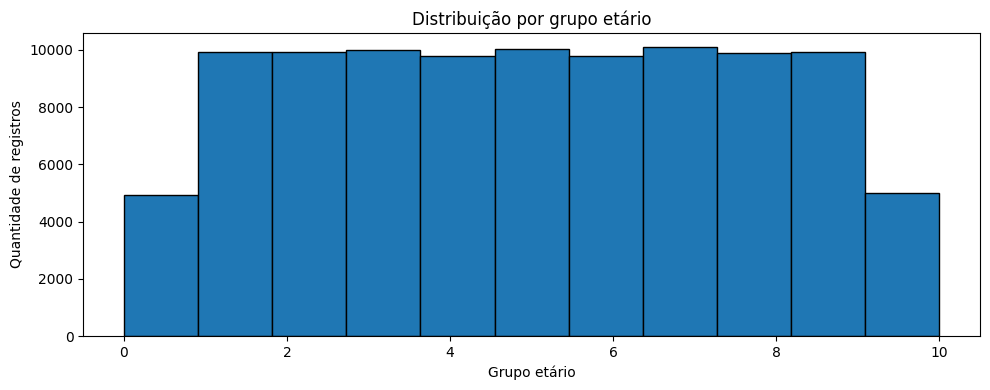

In [22]:
# Histograma da variável age_group
plt.figure(figsize=(10, 4))

plt.hist(df["age_group"].dropna(), bins=11, edgecolor="black")

plt.title("Distribuição por grupo etário")
plt.xlabel("Grupo etário")
plt.ylabel("Quantidade de registros")

plt.tight_layout()
plt.show()

`Nota Técnica - Histograma`

> O histograma da variável `age_group` mostra uma distribuição bastante equilibrada entre os grupos intermediários. Os grupos de 1 a 9 possuem aproximadamente 9,8 mil a 10,1 mil registros cada, enquanto os grupos extremos 0 e 10 possuem cerca de 4,9 mil registros cada. Esse comportamento indica menor frequência nas extremidades e maior concentração uniforme nos grupos centrais. Como a variável é discreta, o histograma deve ser lido como uma contagem por grupo etário, e não como uma curva contínua de densidade.

In [23]:
# Tabela de frequência e proporção da variável age_group
freq_age_group = (
    df["age_group"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("age_group")
    .reset_index(name="frequencia")
)

freq_age_group["proporcao"] = freq_age_group["frequencia"] / len(df)
freq_age_group["proporcao_percentual"] = (
    freq_age_group["proporcao"] * 100
).round(2)

freq_age_group

,age_group,frequencia,proporcao,proporcao_percentual
0,0.0,4927,0.049645,4.96
1,1.0,9913,0.099885,9.99
2,2.0,9923,0.099986,10.00
3,3.0,9985,0.100611,10.06
4,4.0,9792,0.098666,9.87
5,5.0,10034,0.101104,10.11
6,6.0,9786,0.098605,9.86
7,7.0,10085,0.101618,10.16
8,8.0,9884,0.099593,9.96
9,9.0,9917,0.099925,9.99


`Nota Técnica - Tabela de Frequência`

> A tabela de frequência e proporção complementa o histograma ao apresentar a participação de cada grupo etário no conjunto de dados. Os grupos intermediários concentram proporções próximas entre si, enquanto os grupos extremos apresentam participação menor. Essa leitura reforça que `age_group` deve ser analisada como uma variável discreta de grupos, usando contagens e proporções como métricas principais de distribuição.

### 7. EXPORTAR DADOS


In [24]:
# Persistir o conjunto de dados processado em CSV com formatação de datas
df.to_csv(
    "data/processed/customers.csv",
    index=False,
    date_format="%m-%d-%Y %H:%M:%S",
)

### Fim
